In [2]:
# activate virtual environment "masterenv"
import os
activate_this = os.path.join("/home/mueller/MA_researcher_wellbeing/masterenv", "bin", "activate_this.py")
exec(open(activate_this).read(), {'__file__': activate_this})

# import necessary packages
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# import df
timelines_topics = pd.read_json("/home/mueller/MA_researcher_wellbeing/data/timelines_topics.json", lines=True)

In [3]:
timelines_topics.head()

,user_id,created_at,text,is_reply,gender,neg_sent,neutr_sent,pos_sent,topic,prob
0,1079432684,2021-02-16 10:36:42,@NeuroBarbara @PuG2021online @svenpamann I am ...,True,female,0.007144,0.447894,0.544962,-1,0.00000
1,1079432684,2021-02-15 10:35:48,"So excited to start working with you, @impera_...",False,female,0.001824,0.007470,0.990707,195,1.00000
2,1079432684,2021-02-15 10:11:53,We have launched a lab twitter account! For up...,False,female,0.003166,0.544907,0.451927,3793,0.76002
3,1079432684,2021-02-08 17:27:53,@RaschLab Preordered copy has already arrived!...,True,female,0.002222,0.007607,0.990171,-1,0.00000
4,1079432684,2021-02-02 22:23:36,@_rdgao I suggest Il Dolce! It’s a truly Itali...,True,female,0.026895,0.059307,0.913798,-1,0.00000


In [4]:
# define well-being related topic numbers
wb_rel_topics = [4400, 2025, 1600, 16650, 23453, 5336, 11504, 1265, 18289, 3130, 6357, 20843, 2576, 15568, 15109, 7083, 22888, 346, 1065, 2917, 7835, 4709, 471, 2787, 291, 11438, 192, 4849, 604, 22248, 11733, 11020, 19447, 7395, 8747, 10022, 4223, 1590, 114, 1609, 6999, 10861, 10320, 116, 23796, 24324, 232, 2840, 9662, 232, 2130, 12347, 2681, 21203, 22291, 13325, 2235, 58, 5952, 19486, 1956, 13599, 24086, 144, 13568, 7782, 18300, 21197, 6407, 303, 2014, 7442, 22492, 6407, 21988, 12464, 14137, 78, 679, 16179, 22011, 18289, 184, 4615, 1225, 714, 6390, 21, 2022, 539, 2512, 3158, 18036, 543, 17765, 10584, 1166, 24066, 19010, 26, 11367, 14012, 24057, 18, 59, 72, 76, 87, 103, 127, 130, 152, 184, 192, 193, 195, 196]

# filter for well-being related topics
timelines_wb_topics = timelines_topics[timelines_topics["topic"].isin(wb_rel_topics)]

In [5]:
# have a look
timelines_wb_topics.head()

,user_id,created_at,text,is_reply,gender,neg_sent,neutr_sent,pos_sent,topic,prob
1,1079432684,2021-02-15 10:35:48,"So excited to start working with you, @impera_...",False,female,0.001824,0.007470,0.990707,195,1.000000
269,1165001872563933184,2020-07-30 16:54:14,@TheTrafton @Psychonomic_Soc @jeremymwolfe @LW...,True,female,0.005143,0.136976,0.857882,471,0.204768
336,2968559457,2020-12-15 00:46:06,"(By *surprisingly* nice &amp; warm, I do not m...",True,unknown,0.009173,0.030226,0.960601,21,0.536551
463,2968559457,2020-06-15 17:08:22,Happy that our lab was a (small) part of this ...,False,unknown,0.002352,0.007694,0.989955,21,1.000000
559,2968559457,2020-03-29 11:42:38,"In Germany, there is now a lot of discussion a...",False,unknown,0.010611,0.713664,0.275726,196,0.741744


In [6]:
# filter for prob>0.5
timelines_wb_topics = timelines_wb_topics[timelines_wb_topics['prob'] > 0.5]
timelines_wb_topics.head()

,user_id,created_at,text,is_reply,gender,neg_sent,neutr_sent,pos_sent,topic,prob
1,1079432684,2021-02-15 10:35:48,"So excited to start working with you, @impera_...",False,female,0.001824,0.007470,0.990707,195,1.000000
336,2968559457,2020-12-15 00:46:06,"(By *surprisingly* nice &amp; warm, I do not m...",True,unknown,0.009173,0.030226,0.960601,21,0.536551
463,2968559457,2020-06-15 17:08:22,Happy that our lab was a (small) part of this ...,False,unknown,0.002352,0.007694,0.989955,21,1.000000
559,2968559457,2020-03-29 11:42:38,"In Germany, there is now a lot of discussion a...",False,unknown,0.010611,0.713664,0.275726,196,0.741744
635,2968559457,2020-03-18 12:35:59,We have now initiated a regular virtual lab me...,False,unknown,0.003011,0.064288,0.932701,21,0.564135


In [7]:
# save!
timelines_wb_topics.to_json("/home/mueller/MA_researcher_wellbeing/data/timelines_wb_topics.json", orient = "records", lines = True)

In [9]:
# save!
with open("/home/mueller/MA_researcher_wellbeing/data/wb_topic_numbers.json", 'w') as json_file:
    json.dump(wb_rel_topics, json_file)

In [17]:
# prepare dfs for h1 and h2
tm_df = timelines_wb_topics[["created_at", "neg_sent", "pos_sent"]]
n = tm_df.resample("W", on="created_at").size()
tm_df = tm_df.resample("W", on ="created_at").mean()
tm_df["n_all"] = n

tm_df.head()


,neg_sent,pos_sent,n_all
created_at,,,
2019-03-17,0.096505,0.636004,230
2019-03-24,0.111989,0.601701,281
2019-03-31,0.118450,0.630266,288
2019-04-07,0.087650,0.635437,333
2019-04-14,0.122085,0.603428,322


In [18]:
# model week (T) and pandemic (D)
data_len = len(tm_df)
weeks = list(range(1, data_len + 1))
pandemic = [0]*52 + [1]*50

tm_df["week_T"] = weeks
tm_df["pandemic_D"] = pandemic

tm_df.head()

,neg_sent,pos_sent,n_all,week_T,pandemic_D
created_at,,,,,
2019-03-17,0.096505,0.636004,230,1,0
2019-03-24,0.111989,0.601701,281,2,0
2019-03-31,0.118450,0.630266,288,3,0
2019-04-07,0.087650,0.635437,333,4,0
2019-04-14,0.122085,0.603428,322,5,0


In [19]:
# save!
tm_df.to_json("/home/mueller/MA_researcher_wellbeing/data/tm_df.json", orient = "records", lines = True)

### Analysis: POSITIVE

In [20]:
# define df
Y = tm_df["pos_sent"]
T = tm_df["week_T"]
D = tm_df["pandemic_D"]
df = pd.DataFrame({"Y": Y, "T": T, "D": D})

In [21]:
import pmdarima as pm

# fit the ARIMA model automatically 
model = pm.auto_arima(df["Y"], seasonal=False, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-409.464, Time=0.52 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-381.419, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-397.459, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-410.752, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-383.419, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-408.033, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-411.688, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-411.231, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-410.897, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-399.451, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-409.949, Time=0.07 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 1.128 seconds


In [23]:
from statsmodels.tsa.arima.model import ARIMA

# specify ARIMA model using the proposed parameters
arima_results = ARIMA(df["Y"], df[["T", "D"]], order=(0,1,1)).fit()
print(arima_results.summary(alpha=0.025))

                               SARIMAX Results                                
Dep. Variable:                      Y   No. Observations:                  102
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 213.057
Date:                Wed, 15 Nov 2023   AIC                           -418.115
Time:                        14:58:53   BIC                           -407.655
Sample:                    03-17-2019   HQIC                          -413.880
                         - 02-21-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|     [0.0125     0.9875]
------------------------------------------------------------------------------
T             -0.0003      0.001     -0.469      0.639      -0.002       0.001
D             -0.0537      0.023     -2.339      0.019      -0.105      -0.002
ma.L1         -0.8370      0.066    -12.771      0.0

In [ ]:
# Define the number of bootstrap samples
n_bootstrap_samples = 1000
coefficient_D_estimates = []

# Define the block size for block bootstrapping
block_size = 3  # how many segments of data are resampled together (I need a quite small block size to capture short-term variation (effect of the start of the pandemic))

# Perform block bootstrapping
for _ in range(n_bootstrap_samples):
    # Generate a bootstrap sample of 'Y' and 'D' using block bootstrapping
    bootstrap_indices = np.random.randint(1, len(df) - block_size, len(df) // block_size)
    bootstrap_indices = np.repeat(bootstrap_indices, block_size) + np.tile(np.arange(block_size), len(bootstrap_indices))
    bootstrap_sample = df.iloc[bootstrap_indices]

    # Fit ARIMA model to the bootstrap sample
    bootstrap_model = ARIMA(bootstrap_sample["Y"], bootstrap_sample[["T", "D"]], order=(0, 1, 1)).fit()

    # Store the estimated coefficient for 'D'
    coefficient_D_estimates.append(bootstrap_model.params["D"])

# Calculate standard errors and confidence intervals for the coefficient of 'D'
coefficient_D_estimates = np.array(coefficient_D_estimates)
coefficient_D_std_error = coefficient_D_estimates.std()
coefficient_D_ci_lower = np.percentile(coefficient_D_estimates, 1.25)
coefficient_D_ci_upper = np.percentile(coefficient_D_estimates, 98.75)

# Print the results
print("Bootstrap Standard Error for Coefficient of 'D':", coefficient_D_std_error)
print("Bootstrap 97.5% Confidence Interval for Coefficient of 'D':")
print("Lower Bound:", coefficient_D_ci_lower)
print("Upper Bound:", coefficient_D_ci_upper)

    Bootstrap Standard Error for Coefficient of 'D': 0.01715435966540266
    Bootstrap 97.5% Confidence Interval for Coefficient of 'D':
    Lower Bound: -0.07494326264149997
    Upper Bound: 0.0030728162238697933

Text(0, 0.5, 'Positive sentiments')

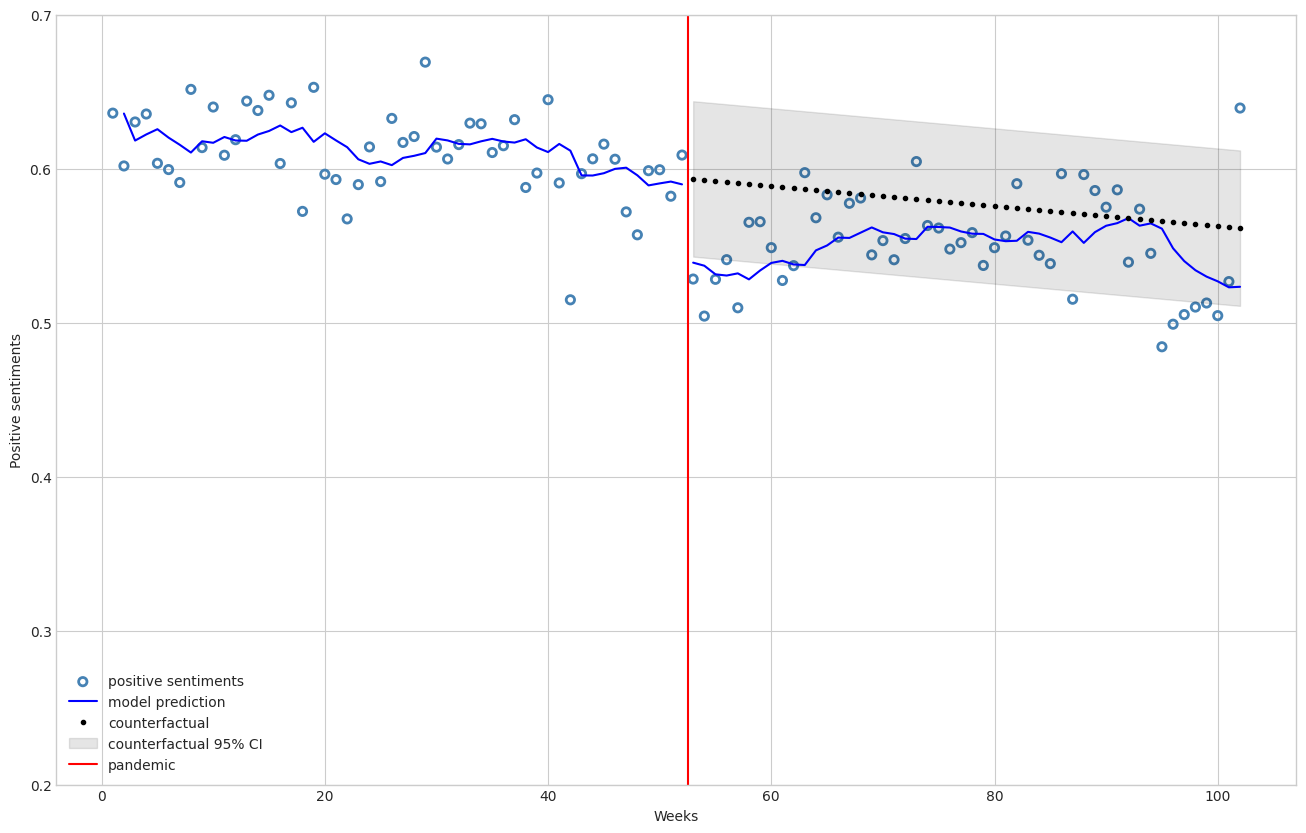

In [25]:
start = 52
end = 102

# get the model predictions for the whole time period (start till end)
predictions = arima_results.get_prediction(0, end-1)
summary = predictions.summary_frame(alpha=0.025)

# get the counterfactual ARIMA by fitting a model only for the first time period (before the pandemic)
arima_cf = ARIMA(df["Y"][:start], df["T"][:start], order=(0,1,1)).fit()

# model predictions means
y_pred = predictions.predicted_mean

# counterfactual mean and 95% confidence interval
y_cf = arima_cf.get_forecast(50, exog=df["T"][start:]).summary_frame(alpha=0.05)

# plot section
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16,10))

# plot weekly sentiment data
ax.scatter(df["T"], df["Y"], facecolors='none', edgecolors='steelblue', label="positive sentiments", linewidths=2)

# plot model mean sentiment prediction
ax.plot(df["T"][1:start], y_pred[1:start], 'b-', label="model prediction")
ax.plot(df["T"][start:], y_pred[start:], 'b-')

# plot counterfactual mean sentiment with 95% confidence interval
ax.plot(df["T"][start:], y_cf["mean"], 'k.', label="counterfactual")
ax.fill_between(df["T"][start:], y_cf['mean_ci_lower'], y_cf['mean_ci_upper'], color='k', alpha=0.1, label="counterfactual 95% CI")


# plot line marking the week of the official start of the pandemic (WHO)
ax.axvline(x = 52.5, color = 'r', label = 'pandemic')

ax.legend(loc='best')
plt.ylim([0.2, 0.7])
plt.xlabel("Weeks")
plt.ylabel("Positive sentiments")

### Analysis: NEGATIVE

In [26]:
# define df
Y = tm_df["neg_sent"]
T = tm_df["week_T"]
D = tm_df["pandemic_D"]
df = pd.DataFrame({"Y": Y, "T": T, "D": D})

In [27]:
import pmdarima as pm

# fit the ARIMA model automatically 
model = pm.auto_arima(df["Y"], seasonal=False, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-513.322, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-486.353, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-502.052, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-488.348, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-516.550, Time=0.11 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-518.016, Time=0.15 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=-514.263, Time=0.12 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=-513.523, Time=0.14 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=-512.706, Time=0.11 sec

Best model:  ARIMA(0,1,3)(0,0,0)[0] intercept
Total fit time: 1.286 seconds


In [28]:
from statsmodels.tsa.arima.model import ARIMA

# specify ARIMA model using the proposed parameters
arima_results = ARIMA(df["Y"], df[["T", "D"]], order=(0,1,3)).fit()
print(arima_results.summary(alpha=0.025))

                               SARIMAX Results                                
Dep. Variable:                      Y   No. Observations:                  102
Model:                 ARIMA(0, 1, 3)   Log Likelihood                 265.849
Date:                Wed, 15 Nov 2023   AIC                           -519.698
Time:                        15:07:21   BIC                           -504.007
Sample:                    03-17-2019   HQIC                          -513.346
                         - 02-21-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|     [0.0125     0.9875]
------------------------------------------------------------------------------
T              0.0005      0.000      2.520      0.012    4.99e-05       0.001
D              0.0169      0.011      1.532      0.126      -0.008       0.042
ma.L1         -0.8095      0.160     -5.044      0.0

/home/mueller/MA_researcher_wellbeing/masterenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Define the number of bootstrap samples
n_bootstrap_samples = 1000
coefficient_D_estimates = []

# Define the block size for block bootstrapping
block_size = 3  # how many segments of data are resampled together (I need a quite small block size to capture short-term variation (effect of the start of the pandemic))

# Perform block bootstrapping
for _ in range(n_bootstrap_samples):
    # Generate a bootstrap sample of 'Y' and 'D' using block bootstrapping
    bootstrap_indices = np.random.randint(1, len(df) - block_size, len(df) // block_size)
    bootstrap_indices = np.repeat(bootstrap_indices, block_size) + np.tile(np.arange(block_size), len(bootstrap_indices))
    bootstrap_sample = df.iloc[bootstrap_indices]

    # Fit ARIMA model to the bootstrap sample
    bootstrap_model = ARIMA(bootstrap_sample["Y"], bootstrap_sample[["T", "D"]], order=(0, 1, 3)).fit()

    # Store the estimated coefficient for 'D'
    coefficient_D_estimates.append(bootstrap_model.params["D"])

# Calculate standard errors and confidence intervals for the coefficient of 'D'
coefficient_D_estimates = np.array(coefficient_D_estimates)
coefficient_D_std_error = coefficient_D_estimates.std()
coefficient_D_ci_lower = np.percentile(coefficient_D_estimates, 1.25)
coefficient_D_ci_upper = np.percentile(coefficient_D_estimates, 98.75)

# Print the results
print("Bootstrap Standard Error for Coefficient of 'D':", coefficient_D_std_error)
print("Bootstrap 97.5% Confidence Interval for Coefficient of 'D':")
print("Lower Bound:", coefficient_D_ci_lower)
print("Upper Bound:", coefficient_D_ci_upper)

    Bootstrap Standard Error for Coefficient of 'D': 0.007364537248176028
    Bootstrap 97.5% Confidence Interval for Coefficient of 'D':
    Lower Bound: -0.0051063942314985
    Upper Bound: 0.02837335763255277

Text(0, 0.5, 'Negative sentiments')

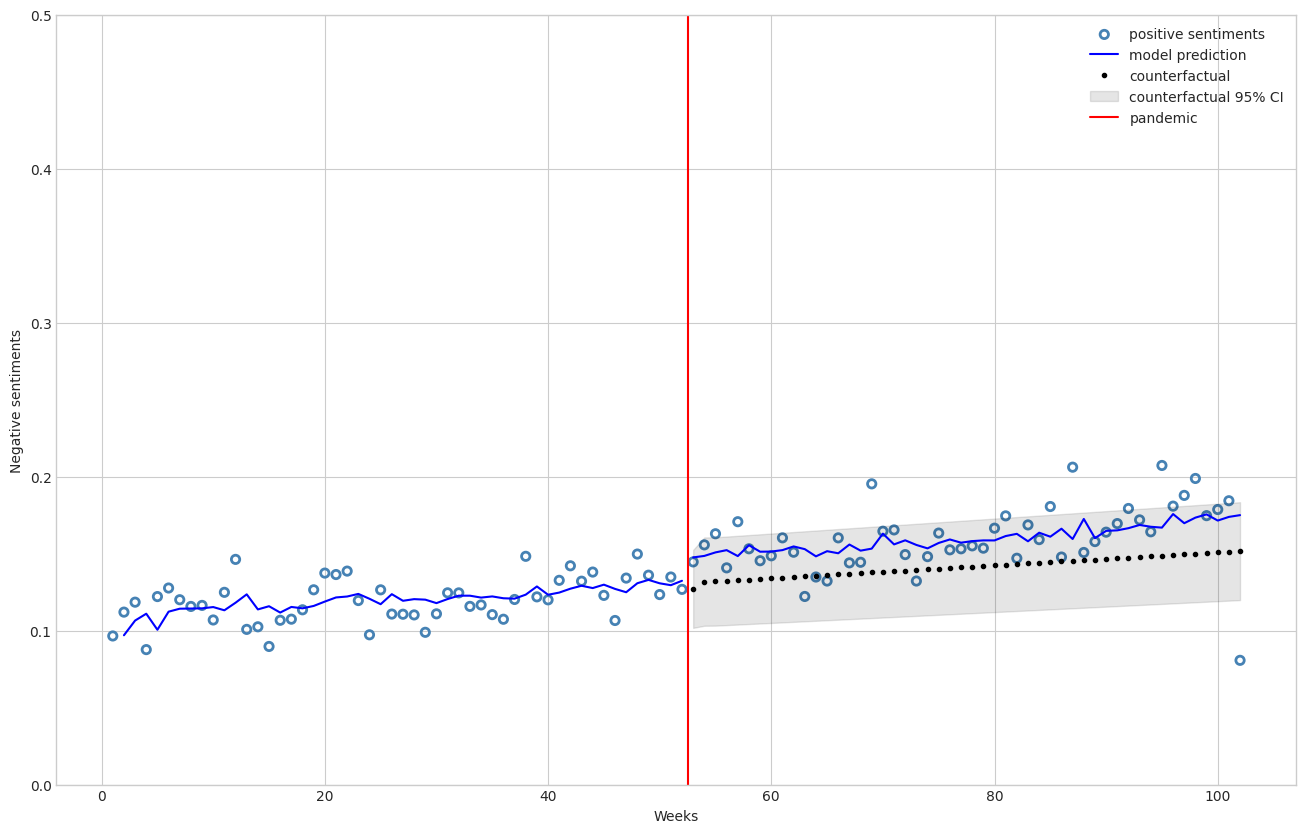

In [30]:
start = 52
end = 102

# get the model predictions for the whole time period (start till end)
predictions = arima_results.get_prediction(0, end-1)
summary = predictions.summary_frame(alpha=0.025)

# get the counterfactual ARIMA by fitting a model only for the first time period (before the pandemic)
arima_cf = ARIMA(df["Y"][:start], df["T"][:start], order=(0,1,3)).fit()

# model predictions means
y_pred = predictions.predicted_mean

# counterfactual mean and 95% confidence interval
y_cf = arima_cf.get_forecast(50, exog=df["T"][start:]).summary_frame(alpha=0.05)

# plot section
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16,10))

# plot weekly sentiment data
ax.scatter(df["T"], df["Y"], facecolors='none', edgecolors='steelblue', label="positive sentiments", linewidths=2)

# plot model mean sentiment prediction
ax.plot(df["T"][1:start], y_pred[1:start], 'b-', label="model prediction")
ax.plot(df["T"][start:], y_pred[start:], 'b-')

# plot counterfactual mean sentiment with 95% confidence interval
ax.plot(df["T"][start:], y_cf["mean"], 'k.', label="counterfactual")
ax.fill_between(df["T"][start:], y_cf['mean_ci_lower'], y_cf['mean_ci_upper'], color='k', alpha=0.1, label="counterfactual 95% CI")


# plot line marking the week of the official start of the pandemic (WHO)
ax.axvline(x = 52.5, color = 'r', label = 'pandemic')

ax.legend(loc='best')
plt.ylim([0, 0.5])
plt.xlabel("Weeks")
plt.ylabel("Negative sentiments")